In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/home/ahmed5311d/Downloads/CSV/cars.csv")
df.rename(columns={"Area_SqFt":"Area", "Build_Year":"BuildYears", "Street_Type":"Street" , "Property_Type":"ProPertyType"},inplace=True)
df.sort_values(by="BuildYears")

,Area,Rooms,BuildYears,Location,Street,Furnishing,ProPertyType,Has_Pool,Price
586,2850.040101,2.0,1985,Lucknow,Residential Lane,Furnished,Independent House,No,646664.0
597,1888.388043,7.0,1985,Noida,Residential Lane,Semi-Furnished,Independent House,Yes,605901.0
820,2138.680067,6.0,1985,Kanpur,Residential Lane,Unfurnished,Independent House,Yes,577915.0
610,2502.933254,2.0,1985,Kanpur,Gated Society,Semi-Furnished,Apartment,No,527024.0
520,1811.298630,6.0,1985,Noida,Residential Lane,Furnished,Independent House,No,579209.0
...,...,...,...,...,...,...,...,...,...
1058,1778.102652,7.0,2024,Jaipur,Residential Lane,Unfurnished,Apartment,No,488949.0
557,1926.687386,7.0,2024,Noida,Corner Plot,Semi-Furnished,Independent House,No,643117.0
549,2881.771204,5.0,2024,Delhi,Residential Lane,Unfurnished,Apartment,No,720187.0
800,1979.496644,3.0,2024,Gurugram,Residential Lane,Furnished,Apartment,No,573593.0


In [4]:
df["Rooms"] = df["Rooms"].fillna( df["Rooms"].mode()[0] )
df["Area"] = df["Area"].fillna( df["Area"].mean() )
df["Furnishing"] = df["Furnishing"].fillna ( "UnKhown" )
# Clean Data Is Done
df.drop_duplicates(inplace=True)

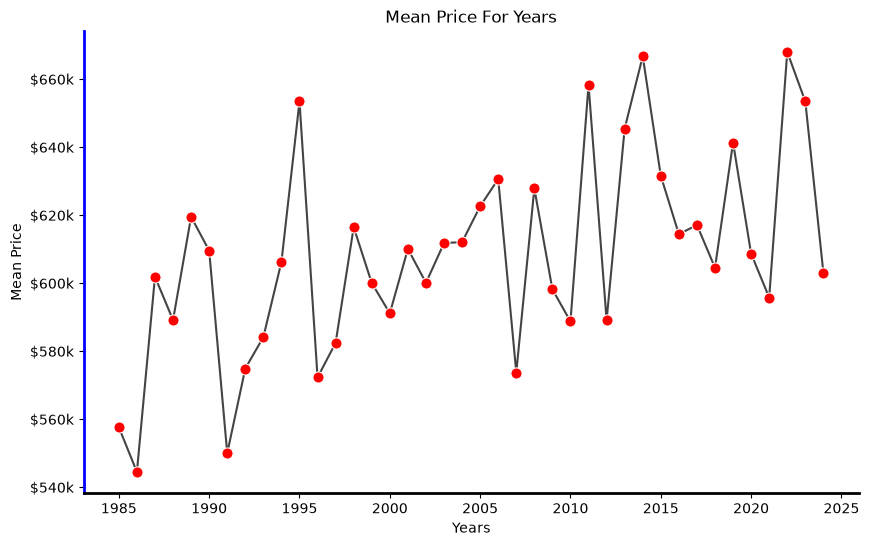

In [11]:
yearsPrice = df.groupby("BuildYears")["Price"].mean().round(3).reset_index()

plt.figure ( figsize = ( 10 , 6 ) )
sns.lineplot(data = yearsPrice, x = "BuildYears", y = "Price", 
             marker = "o", markersize = 8, markerfacecolor = "red",
             linewidth = 1.5, color = '#444444')

plt.title(" Mean Price For Years ")
plt.xlabel(" Years ")
plt.ylabel(" Mean Price ")


def y_format_func(value, tick_number):
    return f"${value/1000:,.0f}k"

from matplotlib.ticker import FuncFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(y_format_func))

# إخفاء الإطار العلوي والأيمن (شائع جداً لجعل الرسمة أرقى)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('blue')     
ax.spines['left'].set_linewidth(2)     
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(2)

plt.savefig("meanPriceForYears.png", dpi=300, bbox_inches='tight')

# ============================================================== #

# The General Market Trend is Upward
# The Lowest Average Occurred in 1986
# The Highest Average Occurred in [ 2015 , 2023 ]

# ============================================================= #

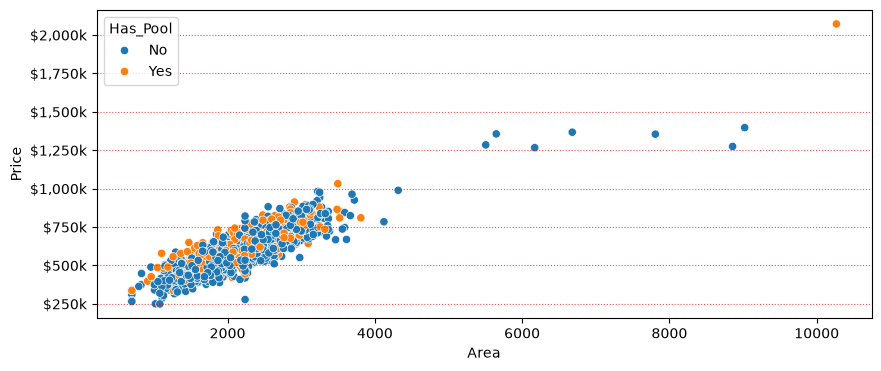

In [21]:
df
plt.figure ( figsize = ( 10 , 4 ) )
sns.scatterplot ( data = df , x = df["Area"] , y = df["Price"] , hue = df["Has_Pool"] )
plt.grid ( axis = "y" , color = "red" , alpha = 0.7 , linestyle = ":" )

def y_format_func(value, tick_number):
    return f"${value/1000:,.0f}k"

from matplotlib.ticker import FuncFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(y_format_func))

# =========================================================== #

# Stacking Occurs between [ : 4000 ] => Area
# The Presence of a Pool not Affect the Price

# =========================================================== #

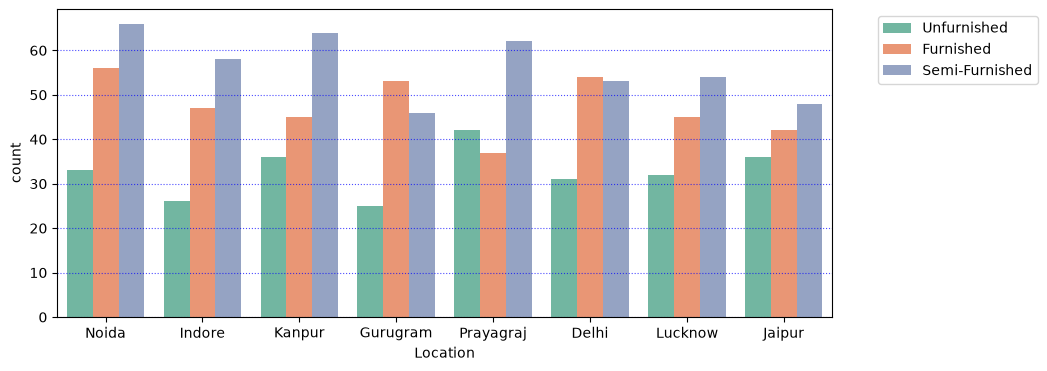

In [46]:
df
countLocation = df.groupby("Location")["Furnishing"].value_counts().reset_index().sort_values(by="count")
countLocation = countLocation [ countLocation != "UnKhown" ]
countLocation.dropna()

plt.figure ( figsize = ( 10 , 4 ) )
sns.barplot ( data = countLocation , x = "Location" , y = "count" , hue = "Furnishing" , palette = 'Set2' )
plt.legend ( bbox_to_anchor = ( 1.05 , 1 ) , loc = "upper left" )
plt.grid ( axis = "y" , color = "blue" , linestyle = ":" , alpha = 0.7 )


# ================================================================================== #

# *Most Popular* 
# ** [ Noida , Kanpur , Prayagraj ] => Semi-Furnished **

# Least Popular
# ** [ Indore , Gurugram , Delhi ] => Unfurnished **

# Delhi => There is a Convergence between ( Furnished , Semi-Furnished ) 
# Prayagraj => This Type Furnished is far more Popular than Others

# ==================================================================================== #